# 시계열 베이스 라인

In [1]:
import os
import numpy as np
import pandas as pd
from plt_rcs import *
import hds

In [2]:
plt.rc(group='figure', figsize=(12, 4))

In [3]:
os.getcwd()

'/Users/taehyunan/Desktop/Repo/SeSAC/Study/sesac_ml_dl_study_repo/project/code/time_series'

In [4]:
os.chdir('../../data')

In [7]:
[i for i in os.listdir() if 'Time' in i][0]

'Synthetic_Time_Series.pkl'

In [8]:
df = pd.read_pickle('Synthetic_Time_Series.pkl')

In [9]:
df.head()

,value
date,
2024-01-01,94.870
2024-01-02,88.220
2024-01-03,88.540
2024-01-04,86.970
2024-01-05,70.205


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 731 entries, 2024-01-01 to 2025-12-31
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   value   731 non-null    float64
dtypes: float64(1)
memory usage: 11.4 KB


In [11]:
df.index

DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
               '2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08',
               '2024-01-09', '2024-01-10',
               ...
               '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-25',
               '2025-12-26', '2025-12-27', '2025-12-28', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[ns]', name='date', length=731, freq='D')

## 실습 데이터셋 분할

In [ ]:
std_date = '2025-01-01' # 기준일자 설정

In [13]:
train = df.loc[:std_date].iloc[:-1]
test = df.loc[std_date:]

In [14]:
display(train.tail())
display(test.head())

,value
date,
2024-12-27,112.650
2024-12-28,96.805
2024-12-29,80.960
2024-12-30,109.240
2024-12-31,112.180


,value
date,
2025-01-01,111.60
2025-01-02,101.77
2025-01-03,111.94
2025-01-04,81.24
2025-01-05,80.41


## 훈련셋과 시험셋 정수 인덱스 생성

In [ ]:
n_train = len(train) # 훈련셋 크기 생성

In [ ]:
train_idx = np.arange(n_train).reshape(-1, 1) # 훈련셋 인덱스를 수치형으로 변환

In [ ]:
n_test = len(test) # 시험셋 크기 생성

In [ ]:
test_idx = np.arange(n_train, n_train + n_test).reshape(-1, 1) # 시험셋 인덱스를 수치형으로 변환

## 기준선 모형 : 단순 기법 예측

In [ ]:
nm_pred = pd.concat(objs=[train, test])['value'].shift(1).loc[test.index]
nm_pred.head()
# date
# 2025-01-01    112.18
# 2025-01-02    111.60
# 2025-01-03    101.77
# 2025-01-04    111.94
# 2025-01-05     81.24
# Freq: D, Name: value, dtype: float64

date
2025-01-01    112.18
2025-01-02    111.60
2025-01-03    101.77
2025-01-04    111.94
2025-01-05     81.24
Freq: D, Name: value, dtype: float64

## 기준선 모형 : 이동 평균 예측

In [ ]:
ma_pred = pd.concat(objs=[train, test])['value'].rolling(window=7).mean().shift(1).loc[test.index]
ma_pred.head()
# date
# 2025-01-01    103.960714
# 2025-01-02    104.509286
# 2025-01-03    103.600714
# 2025-01-04    103.499286
# 2025-01-05    101.275714
# Freq: D, Name: value, dtype: float64

date
2025-01-01    103.960714
2025-01-02    104.509286
2025-01-03    103.600714
2025-01-04    103.499286
2025-01-05    101.275714
Freq: D, Name: value, dtype: float64

## 기준선 모형 : 단순 회귀 기반 예측

In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
model = LinearRegression()

In [29]:
model.fit(X=train_idx, y=train['value'])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
lr_pred = pd.Series(data=model.predict(X=test_idx), index=test.index)
lr_pred.head()
# date
# 2025-01-01    121.615984
# 2025-01-02    121.670329
# 2025-01-03    121.724673
# 2025-01-04    121.779017
# 2025-01-05    121.833362
# Freq: D, dtype: float64

date
2025-01-01    121.615984
2025-01-02    121.670329
2025-01-03    121.724673
2025-01-04    121.779017
2025-01-05    121.833362
Freq: D, dtype: float64

## 기준선 모형 : 표류 기법 예측

In [33]:
y_1, y_t = train['value'].iloc[[0, -1]]

In [34]:
drift = (y_t - y_1) / (n_train - 1)

In [35]:
h = np.arange(1, n_test + 1)

In [ ]:
dm_pred = pd.Series(data=y_t + h * drift, index=test.index)
dm_pred
# date
# 2025-01-01    112.227425
# 2025-01-02    112.274849
# 2025-01-03    112.322274
# 2025-01-04    112.369699
# 2025-01-05    112.417123
#                  ...    
# 2025-12-27    129.300301
# 2025-12-28    129.347726
# 2025-12-29    129.395151
# 2025-12-30    129.442575
# 2025-12-31    129.490000
# Freq: D, Length: 365, dtype: float64

date
2025-01-01    112.227425
2025-01-02    112.274849
2025-01-03    112.322274
2025-01-04    112.369699
2025-01-05    112.417123
                 ...    
2025-12-27    129.300301
2025-12-28    129.347726
2025-12-29    129.395151
2025-12-30    129.442575
2025-12-31    129.490000
Freq: D, Length: 365, dtype: float64

## 기준선 모형의 시각적 비교

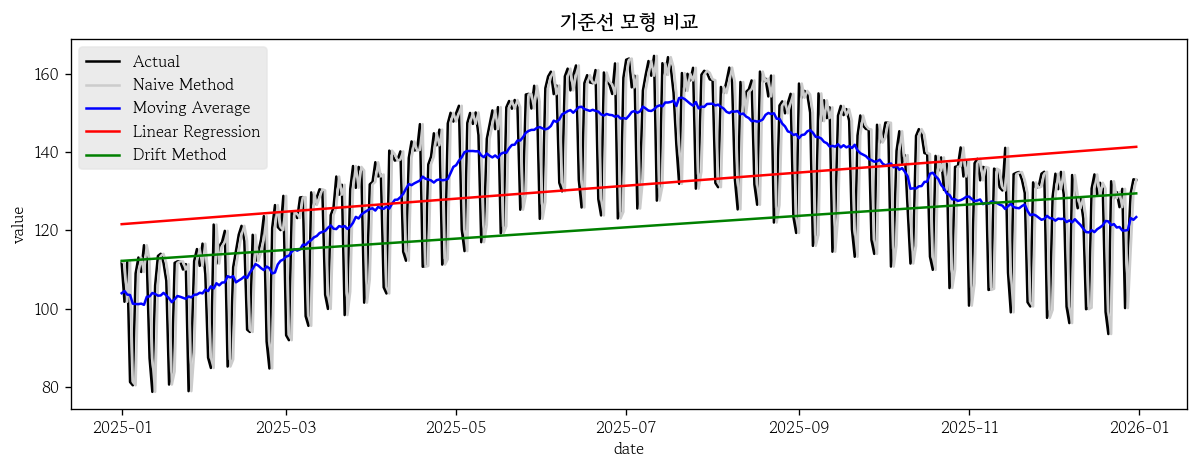

In [38]:
sns.lineplot(x=test.index, y=test['value'], label='Actual', color='0')
sns.lineplot(x=test.index, y=nm_pred, label='Naive Method', color='0.8')
sns.lineplot(x=test.index, y=ma_pred, label='Moving Average', color='blue')
sns.lineplot(x=test.index, y=lr_pred, label='Linear Regression', color='red')
sns.lineplot(x=test.index, y=dm_pred, label='Drift Method', color='green')
plt.title(label='기준선 모형 비교', fontweight='bold')
plt.legend()
plt.show()

In [ ]:
hds.stat.regmetrics(y_true=test['value'], y_pred=nm_pred).loc[[2, 6], ['metric', 'score']].reset_index(drop=True)
# metric	score
# 0	RMSE	16.595267
# 1	MAPE	0.090108

,metric,score
0,RMSE,16.595267
1,MAPE,0.090108


In [ ]:
hds.stat.regmetrics(y_true=test['value'], y_pred=ma_pred).loc[[2, 6], ['metric', 'score']].reset_index(drop=True)
# metric	score
# 0	RMSE	13.931236
# 1	MAPE	0.100994

,metric,score
0,RMSE,13.931236
1,MAPE,0.100994


In [ ]:
hds.stat.regmetrics(y_true=test['value'], y_pred=lr_pred).loc[[2, 6], ['metric', 'score']].reset_index(drop=True)
# metric	score
# 0	RMSE	19.784532
# 1	MAPE	0.131419

,metric,score
0,RMSE,19.784532
1,MAPE,0.131419


In [ ]:
hds.stat.regmetrics(y_true=test['value'], y_pred=dm_pred).loc[[2, 6], ['metric', 'score']].reset_index(drop=True)
# metric	score
# 0	RMSE	22.509184
# 1	MAPE	0.137104

,metric,score
0,RMSE,22.509184
1,MAPE,0.137104
